# Research Dashboard

This notebook creates a lightweight financial research dashboard from retrieval, valuation, and market-style summary data.

Abbreviations used in this notebook:

- **KPI**: Key Performance Indicator.
- **DCF**: Discounted Cash Flow.
- **RAG**: Retrieval-Augmented Generation.
- **WACC**: Weighted Average Cost of Capital.
- **TV**: Terminal Value.
- **PV**: Present Value.
- **EV**: Enterprise Value, the value of the operating business.
- **AI**: Artificial Intelligence.

## 1. Intuition

A dashboard turns system outputs into a compact decision surface. For an AI financial workflow, the dashboard should show valuation, evidence coverage, risk flags, and the current conclusion.

## 2. Mathematics

Dashboard metrics are aggregations:

$$
Evidence\ Coverage = Count(Retrieved\ Documents)
$$

Terminal value share:

$$
TV\ Share = \frac{PV(TV)}{EV}
$$

Upside or downside:

$$
Upside = \frac{Value/Share}{Current\ Price} - 1
$$

## 3. Implementation

We combine the agent valuation output with document coverage and risk flags into dashboard tables.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "06_ai_agents" / "ai_utils.py"
spec = importlib.util.spec_from_file_location("ai_utils", helper_path)
ai_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ai_utils)

plt.style.use("seaborn-v0_8-whitegrid")
documents = ai_utils.sample_financial_documents()

state = ai_utils.answer_valuation_question("Is NESN.SW undervalued and what risks matter?", current_price=96.0)
valuation = state.valuation
current_price = 96.0
upside = valuation["value_per_share"] / current_price - 1

kpis = pd.Series({
    "current_price": current_price,
    "dcf_value_per_share": valuation["value_per_share"],
    "upside_downside": upside,
    "terminal_value_share": valuation["terminal_value_share"],
    "retrieved_documents": len(state.retrieved_documents),
})
kpis.to_frame("value")

,value
current_price,96.000000
dcf_value_per_share,128.899219
upside_downside,0.342700
terminal_value_share,0.829337
retrieved_documents,4.000000


In [2]:
coverage = documents.groupby(["ticker", "source", "section"]).size().reset_index(name="document_count")
risk_flags = pd.Series({
    "terminal_value_high": valuation["terminal_value_share"] > 0.70,
    "upside_material": upside > 0.15,
    "risk_documents_available": (documents["section"] == "risk").any(),
})
coverage.head(), risk_flags.to_frame("flag")

(    ticker         source        section  document_count
 0  NESN.SW  annual_report      cash_flow               1
 1  NESN.SW  annual_report  profitability               1
 2  NESN.SW    market_data          price               1
 3  NESN.SW          model            dcf               1
 4  NESN.SW   risk_factors           risk               1,
                           flag
 terminal_value_high       True
 upside_material           True
 risk_documents_available  True)

## 4. Visualization

The dashboard should make valuation, evidence, and risk visible at a glance.

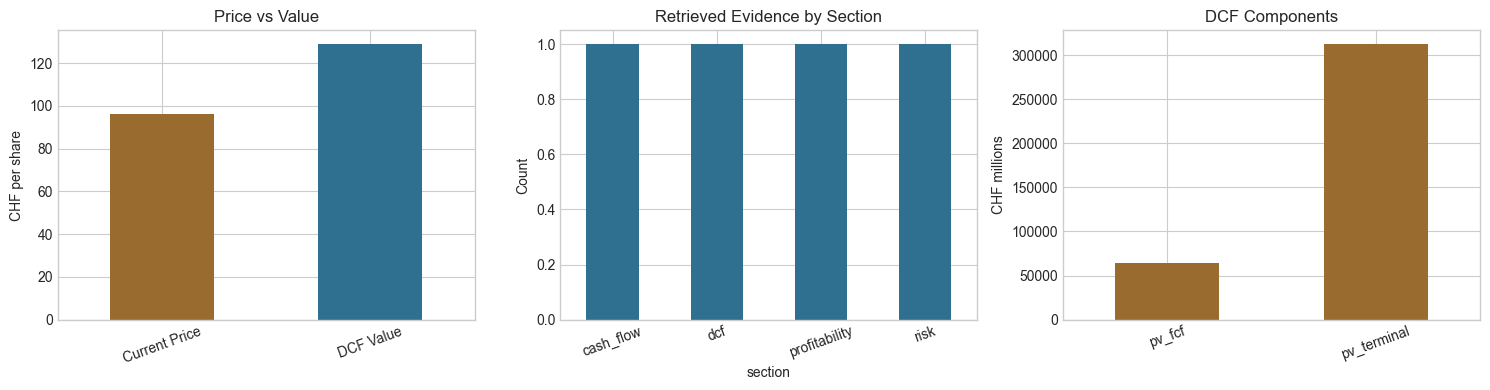

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.Series({"Current Price": current_price, "DCF Value": valuation["value_per_share"]}).plot(kind="bar", ax=axes[0], color=["#9a6b2f", "#2f6f8f"])
axes[0].set_title("Price vs Value")
axes[0].set_ylabel("CHF per share")
axes[0].tick_params(axis="x", rotation=20)

state.retrieved_documents.groupby("section").size().plot(kind="bar", ax=axes[1], color="#2f6f8f")
axes[1].set_title("Retrieved Evidence by Section")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

valuation[["pv_fcf", "pv_terminal"]].plot(kind="bar", ax=axes[2], color="#9a6b2f")
axes[2].set_title("DCF Components")
axes[2].set_ylabel("CHF millions")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 5. Application

A real dashboard can be expanded into an app with live data connectors, document links, model versions, scenario controls, and human review status.

In [4]:
dashboard_summary = pd.DataFrame({
    "item": ["Conclusion", "Main caveat", "Evidence status"],
    "value": [state.conclusion, "DCF sensitive to WACC and terminal growth", "Synthetic offline corpus available"],
})
dashboard_summary

,item,value
0,Conclusion,"The model indicates material upside, but the c..."
1,Main caveat,DCF sensitive to WACC and terminal growth
2,Evidence status,Synthetic offline corpus available


## 6. Reflection

- Dashboards should support decisions, not decorate data.
- Evidence coverage is a first-class metric for AI workflows.
- Risk flags help reviewers focus attention.
- Human review remains important for investment conclusions.

Questions to answer after running the notebook:

1. What KPI is most decision-relevant?
2. Which risk flag should trigger review?
3. What live data source would you connect first?
4. How would you show citations in a production dashboard?